# Nhiệm vụ: Quét ngoại lai & missing values(Bắt các điểm dữ liệu bất thường (người vay quá nhiều, nợ quá cao) và kiểm tra dữ liệu bị lỗi/miss).

In [2]:
# Import thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Lấy data từ file csv

In [3]:
# Đọc data
df = pd.read_csv('../data/Loan_Default.csv')
# Test data

### Cột ditr1(Tỷ lệ Nợ/Thu nhập): Vẽ biểu đồ Hộp (Boxplot) chia theo cột Status. Insight: Phân tích các điểm dữ liệu ngoại lai (những người có dtir cao bất thường - vay mượn quá mức) có rớt hết vào nhóm vỡ nợ không (Status = 1).

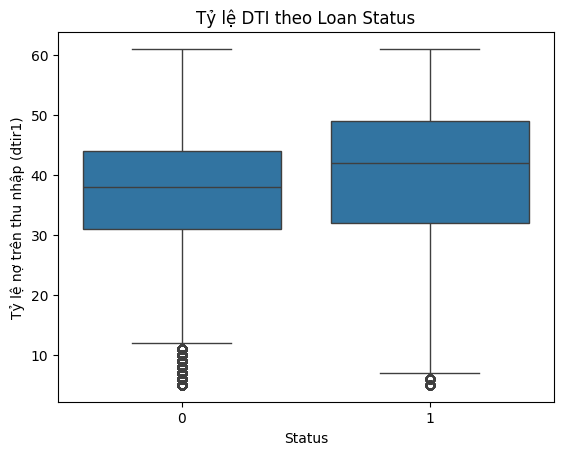

In [23]:
group_by_status_0 = df[df["Status"] == 0]["dtir1"]
group_by_status_1 = df[df["Status"] == 1]["dtir1"]

sns.boxplot(x="Status", y="dtir1", data=df)

plt.title("Tỷ lệ DTI theo Loan Status")
plt.xlabel("Status")
plt.ylabel("Tỷ lệ nợ trên thu nhập (dtir1)")

plt.show()

1. Biểu đồ trên có 2 hộp đại diện cho 2 nhóm với các trục:  
Trục x:  
- 0: Khách hàng không vỡ nợ
- 1: Khách hàng vỡ nợ  
Trục y: đại diện cho tỉ lệ nợ trên thu nhập (dtir1)

2. Đường giữ hộp là Median(trung vị)  
- Cột status 0: quan sát thấy rơi vào khoảng 37-39  
- Cột status 1: quan sát thấy rơi vào khoảng 42-43  
Điều này có nghĩa là:  
Nhóm vỡ nợ có tỷ lệ (nợ/thu nhập) cao hơn hẳn so với nhóm không vỡ nợ

3. Quan sát 2 hộp (Tư phân vị Q1 -> Q3 khoảng 50% dữ liệu)  
- Quan sát thấy hộp có nhóm Status 1 cao hơn hẳn  
- Điều này có nghĩa là: Phần lỡn người vỡ nợ có dtir cao hơn

4. Các chấm tròn (Outlier)
- Các chấm tròn xuất hiện ở phía dưới giao động khoảng từ 5 - 10 (dtir1) => Giá trị bất thường  
- Quan sát thấy các chấm tròn xuất hiện ở cả 2 status => Điều này có nghĩa là tỉ lệ dtir thấp thì không phải không có khả năng vỡ nợ  
- Ngoài ra các chấm tròn xuất hiện nhiều ở nhóm status 0 cho thấy rằng nhóm này có nhiều khách hàng có tỉ lệ nợ trên thu nhập rất thấp

5. Insign
- Boxplot trên đã thể hiện rõ người vay với Status = 1 dự kiến có tỉ lệ dtir cao hơn hẳn so với những người vay có Status = 0  
- Giá trị trung vị DTI (median) của nhóm vỡ nợ là cao hơn, điều này cho thấy rằng khách hàng với tỉ lệ nợ so với thu nhập của bản thân quá cao thì có khả năng cao là vỡ nợ  
- Tuy nhiên vì sự xuất hiện của các giá trị ngoại lai (outlier) cho thấy rằng nguy cơ vỡ nợ còn bị ảnh hưởng bởi các yếu tố bổ sung ngoài DTI


### Cột loan_amount & property_value: Vẽ Boxplot chung để xem phân phối số tiền. Insight: Xác định xem quy mô khoản vay tập trung ở mốc bao nhiêu tiền, mức vay tối đa trong tập dữ liệu là bao nhiêu.

Giá trị số tiền vay: 3576500


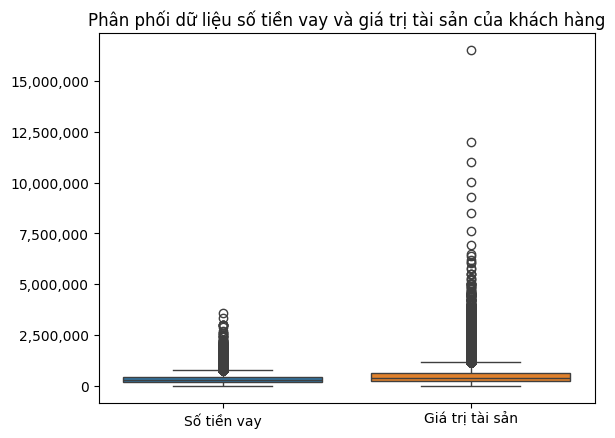

In [ ]:
sns.boxplot(data=df[['loan_amount', 'property_value']])

plt.title("Phân phối dữ liệu số tiền vay và giá trị tài sản của khách hàng")
plt.xticks([0, 1], ['Số tiền vay', 'Giá trị tài sản'])
plt.gca().get_yaxis().set_major_formatter('{x:,.0f}')
max_loan_data = df["loan_amount"].max()
print("Giá trị số tiền vay lớn nhất:", max_loan_data)
plt.show()

1. Phân tích biểu đồ  
- Nhìn vào biểu đồ ta thấy được 2 cột là:  
Cột x:  
+ Hộp bên trái là loan_amount (Số tiền vay)
+ Hộp bên phải property_value (Giá trị tài sản)  
Cột y: Chứa giả trị về số tiền 

2. Ý nghĩa từng phần giá trị
- Mỗi hộp đều có 3 phần: Đáy hộp (Q1 25% dữ liệu, Q3 75% dữ liệu, Đường giữa hộp là: Median(trung vị))
- Cả hộp chứa 50% dữ liệu trung tâm (Q1 -> Q3)

3. Các chấm tròn phía trên (outliers)
- Các chấm tròn outliers là các giá trị bất thường
- Các giá trị này đại diện cho 1 khoản vay cực lớn hoặc giá trị tài sản cực lớn

4. Insigh
- Thông qua biểu đồ trên, ta quan sát thấy được phần lớn giá trị loan_amount (số tiền vay) tập trung ở khoản khá thấp dao động từ khoảng trên dưới 100.000 đến dưới 5.000.000 so với (giá trị tài sản) property_value
- Giá trị property_value cao hơn hẳn so với khoản vay cho thấy rằng điều này vô cùng hợp lý vì các hệ thống ngân hàng chỉ cho vay số tiền tương ứng dựa trên 1 phần giá trị tài sản
- Biểu đồ xuất hiện khá nhiều outliers cho thấy rằng tồn tại 1 số khoản vay và giá trị tài sản khá lớn so với phần chung dữ liệu hiện có
- Mức vay tối đa dựa trên tài sản hiện có có thể quan sát được trên biểu đồ khoản hơn 3.500.000 1 tí (cụ thể là 3.576.500)

### Cột Upfront_charges: Tính toán đếm số dòng bị thiếu dữ liệu và in ra màn hình. Vẽ Histogram để xem phân phối. Insight: Phân tích tỷ lệ phần trăm dữ liệu bị khuyết  (Missing values).

Số dòng bị thiếu dữ liệu: 39642
Tỷ lệ missing: 26.66%


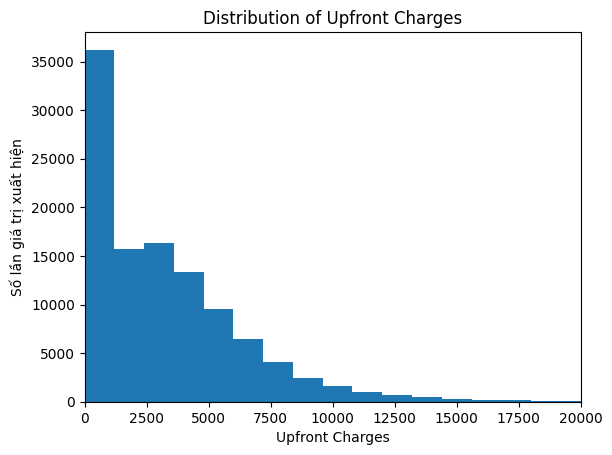

In [ ]:
missing_count = df["Upfront_charges"].isnull().sum()
print(f"Số dòng bị thiếu dữ liệu: {missing_count}")

total_rows = len(df)

missing_percent = (missing_count / total_rows) * 100
print(f"Tỷ lệ missing: {missing_percent:.2f}%")

plt.hist(df["Upfront_charges"].dropna(), bins=50)
plt.xlim(0, 20000)
plt.title("Biểu đồ phân phối theo Upfront Charges")
plt.xlabel("Upfront Charges")
plt.ylabel("Số lần giá trị xuất hiện")
plt.show()

#### Phân tích biểu đồ
1. Phân phối dữ liệu 
- Ta quan sát được phần lớn dữ liệu tập trung ở vùng thấp phía bên trái (khoảng 0 -> 3000) và giảm dần về 0 ở phía bên phải khoảng trên 10000
- Điều đó chứng tỏ khi giá trị tăng lên thì tần suất xuất hiện giảm dần -> Đa số khách hàng chi trả chi phí upfront thấp

2. Dạng phân phối
- Biểu đồ có xu hướng lệch về bên phải có thể gọi là phân phối lệch phải
- Điều này lý giải được: Nhiều giá trị nhỏ, ít giá trị lớn.

3. Outlirs (Giá trị ngoại tệ)
- Ở phía từ 12500 -> 20000 có rất ít dữ liệu xuất hiện -> điều này có thể gọi là outliers
- Ngoài ra ở phía từ 0 -> khoảng 1250 cũng có rất ít dữ liệu cực lớn xuất hiện cũng có thể gọi là outliers

#### Insign
- Có khoảng 39642 dòng bị thiếu dữ liệu chiếm khoảng 26,66% trong cột Upfront_charges -> Điều này cho thấy rằng dữ liệu có 1 số lượng missing khá lớn và cần được xử lý trước khi đưa vào mô hình hoạt động
- Biếu đồ Histogram có xu hướng phân phối lệch phải
- Dựa vào Histogram cho thấy rằng lượng phân phối của Upfront_charges có dữ liệu tập trung nhiều đáng kể ở khoảng từ 0 -> khoảng trên dưới 1250 và giảm dần sau đó cho thấy hầu hết khách hàng phải trả upfront thấp
- Các khoảng outliers tồn tại trên 12500 vì dữ liệu xuất hiện với tần suất thấp ngoài ra cũng tồn tại ở khoảng từ 0 -> trên dưới 1250  
